In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Data Preprocessing****

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/dibyabhowmik/hotel-booking/Hotel booking.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/dibyabhowmik/hotel-booking/Hotel booking.csv')

# Display the first 5 rows
display(df.head())

# Check dataset dimensions
print("Dataset Shape:", df.shape)

# Check column names
print("\nColumn Names:")
print(df.columns.tolist())

# Check data types
print("\nData Types:")
display(df.dtypes)

# Check missing values
print("\nMissing Values:")
missing_values = df.isnull().sum().sort_values(ascending=False)
display(missing_values[missing_values > 0])

# Check duplicate rows
print("\nNumber of Duplicate Rows:", df.duplicated().sum())

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,02-07-2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,02-07-2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,03-07-2015


Dataset Shape: (119390, 32)

Column Names:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

Data Types:


hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             


Missing Values:


company     112593
agent        16340
country        488
children         4
dtype: int64


Number of Duplicate Rows: 31994


Handling Missing Values

In [5]:
# Check missing values before handling
print("Missing values before handling:")
display(df[['company', 'agent', 'country', 'children']].isnull().sum())

# Handle missing values

# Missing company/agent means no company or agent was recorded
df['company'] = df['company'].fillna(0)
df['agent'] = df['agent'].fillna(0)

# Missing country is retained as an Unknown category
df['country'] = df['country'].fillna('Unknown')

# Missing children values are treated as 0
df['children'] = df['children'].fillna(0)

# Check missing values after handling
print("\nMissing values after handling:")
display(df[['company', 'agent', 'country', 'children']].isnull().sum())

Missing values before handling:


company     112593
agent        16340
country        488
children         4
dtype: int64


Missing values after handling:


company     0
agent       0
country     0
children    0
dtype: int64

Convert Date Columns

In [6]:
# Create a complete arrival date
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'] + '-' +
    df['arrival_date_day_of_month'].astype(str),
    errors='coerce'
)

# Convert reservation status date to datetime
df['reservation_status_date'] = pd.to_datetime(
    df['reservation_status_date'],
    errors='coerce'
)

# Check the data types
print("Date column data types:")
print(df[['arrival_date', 'reservation_status_date']].dtypes)

# Display sample dates
print("\nSample dates:")
display(df[['arrival_date', 'reservation_status_date']].head())

Date column data types:
arrival_date               datetime64[ns]
reservation_status_date    datetime64[ns]
dtype: object

Sample dates:


,arrival_date,reservation_status_date
0,2015-07-01,2015-01-07
1,2015-07-01,2015-01-07
2,2015-07-01,2015-02-07
3,2015-07-01,2015-02-07
4,2015-07-01,2015-03-07


Remove Duplicate Records

In [7]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# Check the dataset shape after removing duplicates
print("\nDataset shape after removing duplicates:", df.shape)

print("Duplicate rows remaining:", df.duplicated().sum())

Number of duplicate rows: 32077

Dataset shape after removing duplicates: (87313, 33)
Duplicate rows remaining: 0


Create Derived Columns

In [8]:
# Total number of nights stayed
df['total_nights'] = (
    df['stays_in_weekend_nights'] +
    df['stays_in_week_nights']
)

# Total number of guests
df['total_guests'] = (
    df['adults'] +
    df['children'] +
    df['babies']
)

# Estimated lodging revenue
df['lodging_revenue'] = (
    df['adr'] * df['total_nights']
)

# Display the new columns
display(
    df[
        [
            'stays_in_weekend_nights','stays_in_week_nights','total_nights','adults','children','babies','total_guests',
            'adr',
            'lodging_revenue'
        ]
    ].head()
)

# Check the new columns
print("New columns created:")
print(['total_nights', 'total_guests', 'lodging_revenue'])

,stays_in_weekend_nights,stays_in_week_nights,total_nights,adults,children,babies,total_guests,adr,lodging_revenue
0,0,0,0,2,0.0,0,2.0,0.0,0.0
1,0,0,0,2,0.0,0,2.0,0.0,0.0
2,0,1,1,1,0.0,0,1.0,75.0,75.0
3,0,1,1,1,0.0,0,1.0,75.0,75.0
4,0,2,2,2,0.0,0,2.0,98.0,196.0


New columns created:
['total_nights', 'total_guests', 'lodging_revenue']


Basic Question****

Question 1

In [12]:
average_lead_time = df['lead_time'].mean()

print(f"Average booking lead time: {average_lead_time:.2f} days")

Average booking lead time: 79.84 days


Question 2

Booking Distribution by Hotel Type:


hotel
City Hotel      53372
Resort Hotel    33940
Name: count, dtype: int64

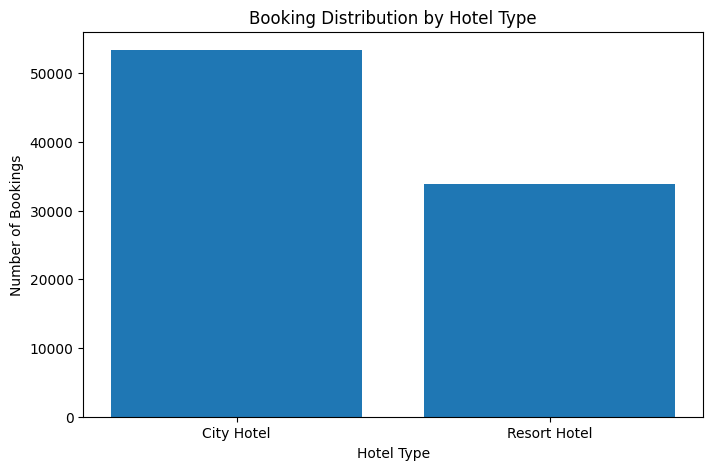

In [13]:
hotel_booking_counts = df['hotel'].value_counts()

print("Booking Distribution by Hotel Type:")
display(hotel_booking_counts)

# Bar chart
plt.figure(figsize=(8, 5))
plt.bar(hotel_booking_counts.index, hotel_booking_counts.values)

plt.title('Booking Distribution by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')

plt.show()

Question 3

In [14]:
canceled_bookings = df['is_canceled'].sum()

print(f"Number of canceled bookings: {canceled_bookings}")

Number of canceled bookings: 23942


Question 4

In [15]:
# Count bookings by arrival month
monthly_bookings = df['arrival_date_month'].value_counts()

print("Bookings by Arrival Month:")
display(monthly_bookings)

# Find month with the highest number of bookings
most_common_month = monthly_bookings.idxmax()
highest_booking_count = monthly_bookings.max()

print(f"\nMonth with the most bookings: {most_common_month}")
print(f"Number of bookings: {highest_booking_count}")

Bookings by Arrival Month:


arrival_date_month
August       11251
July         10048
May           8340
April         7897
June          7760
March         7509
October       6926
September     6678
February      6095
December      5126
November      4991
January       4691
Name: count, dtype: int64


Month with the most bookings: August
Number of bookings: 11251


Question 5

In [16]:
average_special_requests = df['total_of_special_requests'].mean()

print(f"Average special requests per booking: {average_special_requests:.2f}")

Average special requests per booking: 0.70


Question 6

In [17]:
# Count bookings by country
country_bookings = df['country'].value_counts()

print("Top 10 Countries by Number of Bookings:")
display(country_bookings.head(10))

# Find the country with the highest number of bookings
top_country = country_bookings.idxmax()
top_country_count = country_bookings.max()

print(f"\nCountry with the highest number of bookings: {top_country}")
print(f"Number of bookings: {top_country_count}")

Top 10 Countries by Number of Bookings:


country
PRT    27405
GBR    10424
FRA     8837
ESP     7249
DEU     5386
ITA     3060
IRL     3011
BEL     2081
BRA     1995
NLD     1910
Name: count, dtype: int64


Country with the highest number of bookings: PRT
Number of bookings: 27405


Question 7

In [18]:
# Calculate average ADR for each hotel type
average_adr_by_hotel = (
    df.groupby('hotel')['adr']
    .mean()
    .sort_values(ascending=False)
)

print("Average ADR by Hotel Type:")
display(average_adr_by_hotel)

Average ADR by Hotel Type:


hotel
City Hotel      110.996807
Resort Hotel     99.036076
Name: adr, dtype: float64

Question 8

In [19]:
# Count bookings requiring at least one parking space
parking_required = (df['required_car_parking_spaces'] > 0).sum()

# Calculate percentage
parking_percentage = (
    parking_required / len(df)
) * 100

print(f"Bookings requiring parking: {parking_required}")
print(f"Percentage of bookings requiring parking: {parking_percentage:.2f}%")

Bookings requiring parking: 7313
Percentage of bookings requiring parking: 8.38%


Question 9

In [20]:
# Calculate average weekday and weekend stay duration
average_weekend_nights = df['stays_in_weekend_nights'].mean()
average_week_nights = df['stays_in_week_nights'].mean()

print(f"Average weekend nights: {average_weekend_nights:.2f}")
print(f"Average weekday nights: {average_week_nights:.2f}")

average_total_nights = df['total_nights'].mean()

print(f"Average total stay duration: {average_total_nights:.2f} nights")

Average weekend nights: 1.01
Average weekday nights: 2.63
Average total stay duration: 3.63 nights


Question 10

In [21]:
travel_agent_bookings = df['agent'].ne(0).sum()

print(f"Number of bookings made through travel agents: {travel_agent_bookings}")

Number of bookings made through travel agents: 75126


Medium Level****

Question 1

In [22]:
cancellation_rate_by_hotel = (
    df.groupby('hotel')['is_canceled']
    .mean() * 100
)

print("Cancellation Rate by Hotel Type:")
display(cancellation_rate_by_hotel.round(2))

Cancellation Rate by Hotel Type:


hotel
City Hotel      29.97
Resort Hotel    23.42
Name: is_canceled, dtype: float64

Question 2

In [23]:
average_adr_by_segment = (
    df.groupby('market_segment')['adr']
    .mean()
    .sort_values(ascending=False)
)

print("Average ADR by Market Segment:")
display(average_adr_by_segment.round(2))

Average ADR by Market Segment:


market_segment
Online TA        118.18
Direct           116.59
Aviation         100.17
Offline TA/TO     81.74
Groups            74.90
Corporate         68.15
Undefined         15.00
Complementary      3.05
Name: adr, dtype: float64

Question 3

Cancellation Rate by Booking Lead Time:


lead_time_range
0–7 days         8.42
8–30 days       25.34
31–60 days      31.54
61–90 days      32.46
91–180 days     34.90
181–365 days    39.57
365+ days       40.67
Name: is_canceled, dtype: float64

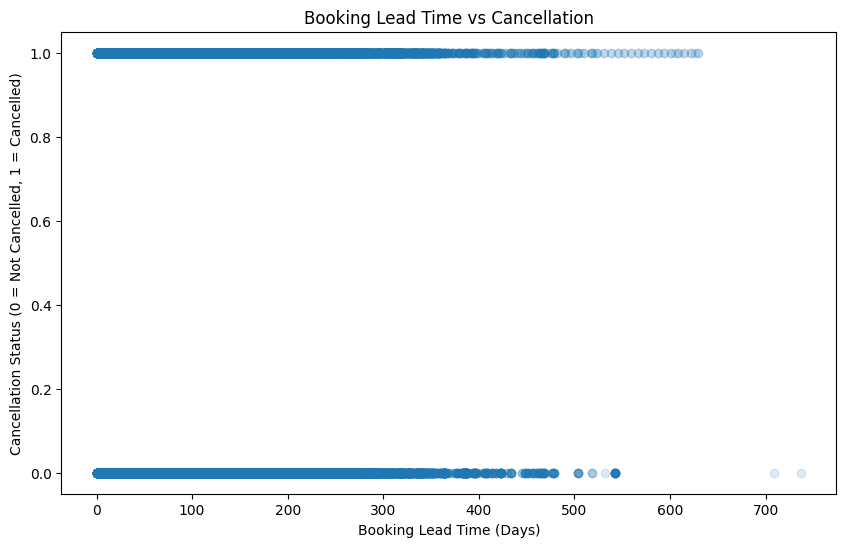

In [24]:
lead_time_bins = [0, 7, 30, 60, 90, 180, 365, float('inf')]
lead_time_labels = [
    '0–7 days','8–30 days','31–60 days','61–90 days','91–180 days','181–365 days','365+ days']

df['lead_time_range'] = pd.cut(
    df['lead_time'],
    bins=lead_time_bins,
    labels=lead_time_labels,
    include_lowest=True
)

# Calculate cancellation rate for each lead-time range
cancellation_by_lead_time = (
    df.groupby('lead_time_range', observed=False)['is_canceled']
    .mean() * 100
)

print("Cancellation Rate by Booking Lead Time:")
display(cancellation_by_lead_time.round(2))

# Visualize the relationship
plt.figure(figsize=(10, 6))

plt.scatter(
    df['lead_time'],
    df['is_canceled'],
    alpha=0.15
)

plt.title('Booking Lead Time vs Cancellation')
plt.xlabel('Booking Lead Time (Days)')
plt.ylabel('Cancellation Status (0 = Not Cancelled, 1 = Cancelled)')

plt.show()

Question 4

In [25]:
distribution_channel_counts = (
    df['distribution_channel']
    .value_counts()
)

print("Bookings by Distribution Channel:")
display(distribution_channel_counts)

# Identify the channel with the most bookings
top_distribution_channel = distribution_channel_counts.idxmax()
top_distribution_count = distribution_channel_counts.max()

print(f"\nDistribution channel with the most bookings: {top_distribution_channel}")
print(f"Number of bookings: {top_distribution_count}")

Bookings by Distribution Channel:


distribution_channel
TA/TO        69066
Direct       12981
Corporate     5079
GDS            181
Undefined        5
Name: count, dtype: int64


Distribution channel with the most bookings: TA/TO
Number of bookings: 69066


Question 5

In [27]:
average_previous_cancellations = (
    df.groupby('hotel')['previous_cancellations']
    .mean()
    .sort_values(ascending=False)
)

print("Average Previous Cancellations by Hotel Type:")
display(average_previous_cancellations.round(2))

Average Previous Cancellations by Hotel Type:


hotel
City Hotel      0.04
Resort Hotel    0.02
Name: previous_cancellations, dtype: float64

Question 6

Average ADR by Year:


arrival_date_year
2015     92.18
2016    101.54
2017    118.72
Name: adr, dtype: float64

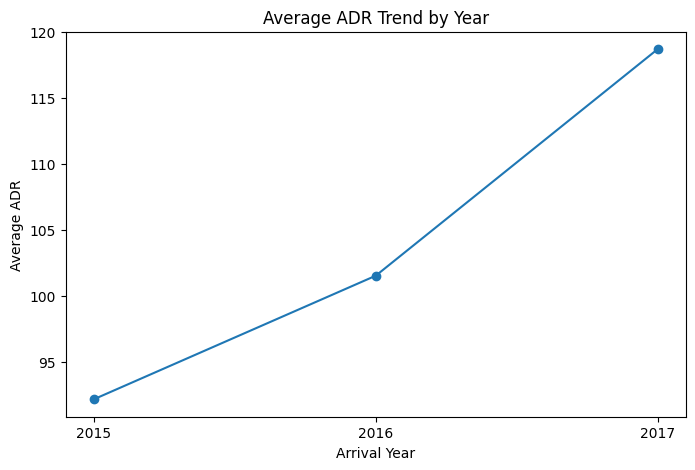

In [28]:
average_adr_by_year = (
    df.groupby('arrival_date_year')['adr']
    .mean()
    .sort_index()
)

print("Average ADR by Year:")
display(average_adr_by_year.round(2))


plt.figure(figsize=(8, 5))

plt.plot(
    average_adr_by_year.index,
    average_adr_by_year.values,
    marker='o'
)

plt.title('Average ADR Trend by Year')
plt.xlabel('Arrival Year')
plt.ylabel('Average ADR')
plt.xticks(average_adr_by_year.index)

plt.show()

Question 7

Total Lodging Revenue by Month:


arrival_date_month
January       705407.21
February     1025077.03
March        1416110.95
April        1805375.46
May          2060619.53
June         2296399.43
July         3799350.53
August       4608288.90
September    1970554.65
October      1476094.71
November      893645.61
December      920036.12
Name: lodging_revenue, dtype: float64


Month with the highest revenue: August
Total revenue: 4,608,288.90


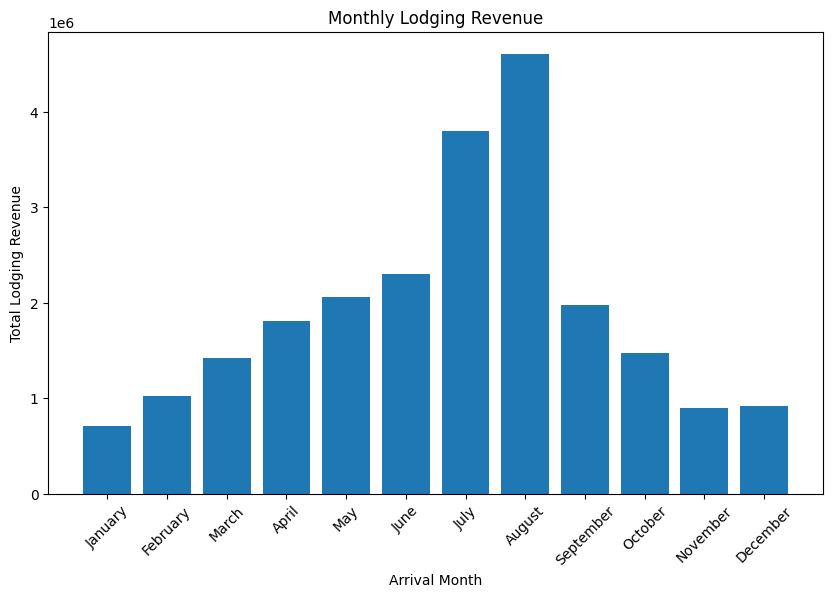

In [29]:
non_canceled = df[df['is_canceled'] == 0].copy()

# Calculate total lodging revenue by arrival month
monthly_revenue = (
    non_canceled.groupby('arrival_date_month')['lodging_revenue']
    .sum()
)

# Arrange months chronologically
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_revenue = monthly_revenue.reindex(month_order)

print("Total Lodging Revenue by Month:")
display(monthly_revenue.round(2))

# Identify the highest-revenue month
highest_revenue_month = monthly_revenue.idxmax()
highest_revenue = monthly_revenue.max()

print(f"\nMonth with the highest revenue: {highest_revenue_month}")
print(f"Total revenue: {highest_revenue:,.2f}")

# Plot monthly revenue
plt.figure(figsize=(10, 6))

plt.bar(monthly_revenue.index, monthly_revenue.values)

plt.title('Monthly Lodging Revenue')
plt.xlabel('Arrival Month')
plt.ylabel('Total Lodging Revenue')

plt.xticks(rotation=45)
plt.show()

Question 8

Correlation between special requests and ADR: 0.1379


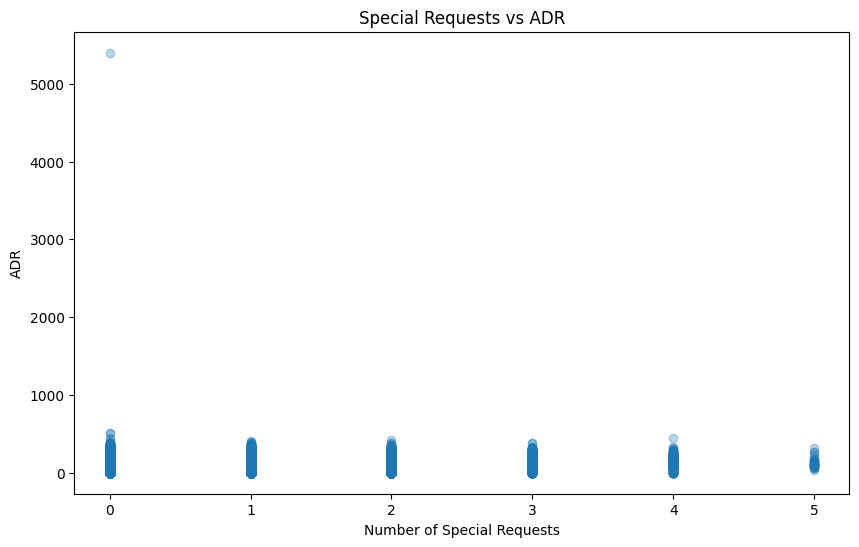

In [30]:
special_requests_adr_correlation = (
    df['total_of_special_requests'].corr(df['adr'])
)

print(
    f"Correlation between special requests and ADR: "
    f"{special_requests_adr_correlation:.4f}"
)


plt.figure(figsize=(10, 6))

plt.scatter(
    df['total_of_special_requests'],
    df['adr'],
    alpha=0.3
)

plt.title('Special Requests vs ADR')
plt.xlabel('Number of Special Requests')
plt.ylabel('ADR')

plt.show()

Question 9

In [31]:
average_stay_by_guest_type = (
    df.groupby('is_repeated_guest')['total_nights']
    .mean()
)

average_stay_by_guest_type.index = [
    'New Guests' if value == 0 else 'Repeated Guests'
    for value in average_stay_by_guest_type.index
]

print("Average Stay Duration by Guest Type:")
display(average_stay_by_guest_type.round(2))

Average Stay Duration by Guest Type:


New Guests         3.70
Repeated Guests    1.92
Name: total_nights, dtype: float64

Question 10

Bookings by Reserved Room Type:


reserved_room_type
A    56484
D    17385
E     6047
F     2823
G     2051
B      999
C      915
H      596
L        6
P        6
Name: count, dtype: int64


Room type with the highest number of bookings: A
Number of bookings: 56484


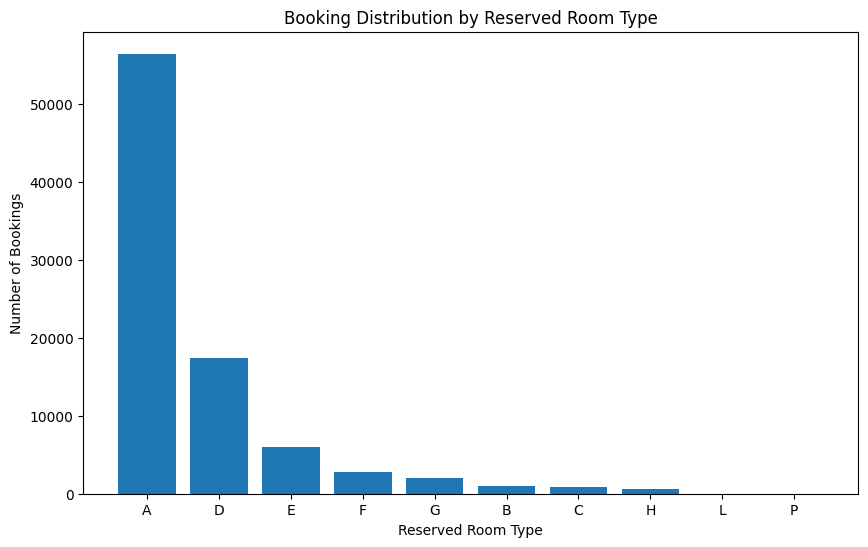

In [32]:
room_type_bookings = (
    df['reserved_room_type']
    .value_counts()
    .sort_values(ascending=False)
)

print("Bookings by Reserved Room Type:")
display(room_type_bookings)


top_room_type = room_type_bookings.idxmax()
top_room_count = room_type_bookings.max()

print(f"\nRoom type with the highest number of bookings: {top_room_type}")
print(f"Number of bookings: {top_room_count}")


plt.figure(figsize=(10, 6))
plt.bar(room_type_bookings.index, room_type_bookings.values)

plt.title('Booking Distribution by Reserved Room Type')
plt.xlabel('Reserved Room Type')
plt.ylabel('Number of Bookings')

plt.show()

Advance Level

Question 1

In [34]:
import statsmodels.api as sm

# Select variables relevant to cancellation
model_data = df[
    [
        'is_canceled',
        'lead_time',
        'booking_changes',
        'previous_cancellations',
        'previous_bookings_not_canceled',
        'total_of_special_requests',
        'deposit_type',
        'market_segment',
        'customer_type'
    ]
].copy()

# Treat Undefined market segment as missing
model_data['market_segment'] = model_data['market_segment'].replace(
    'Undefined', pd.NA
)

# Remove missing values
model_data = model_data.dropna()

# Convert categorical variables into dummy variables
model_data = pd.get_dummies(
    model_data,
    columns=['deposit_type', 'market_segment', 'customer_type'],
    drop_first=True
)

# Convert Boolean columns to integers
bool_columns = model_data.select_dtypes(include='bool').columns
model_data[bool_columns] = model_data[bool_columns].astype(int)

# Separate dependent and independent variables
X = model_data.drop(columns='is_canceled')
y = model_data['is_canceled']

# Add intercept
X = sm.add_constant(X)

# Fit logistic regression with more iterations
logit_model = sm.Logit(y, X)

result = logit_model.fit(
    maxiter=200,
    disp=True
)

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.496519
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:            is_canceled   No. Observations:                87310
Model:                          Logit   Df Residuals:                    87293
Method:                           MLE   Df Model:                           16
Date:                Mon, 14 Sep 2026   Pseudo R-squ.:                  0.1547
Time:                        14:33:54   Log-Likelihood:                -43351.
converged:                       True   LL-Null:                       -51285.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -1.8883      0.183    -10.340     

Question 2

In [35]:
# Select variables
adr_data = df[
    ['adr', 'adults', 'children', 'babies']
].copy()

# Remove missing values
adr_data = adr_data.dropna()

# Separate dependent and independent variables
X = adr_data[['adults', 'children', 'babies']]
y = adr_data['adr']

# Add intercept
X = sm.add_constant(X)

# Fit multiple linear regression
adr_model = sm.OLS(y, X).fit()

# Display regression results
print(adr_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    adr   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.165
Method:                 Least Squares   F-statistic:                     5743.
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:35:23   Log-Likelihood:            -4.6596e+05
No. Observations:               87312   AIC:                         9.319e+05
Df Residuals:                   87308   BIC:                         9.320e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         61.2050      0.539    113.631      0.0

Question 3

Correlation between booking changes and special requests: 0.0160


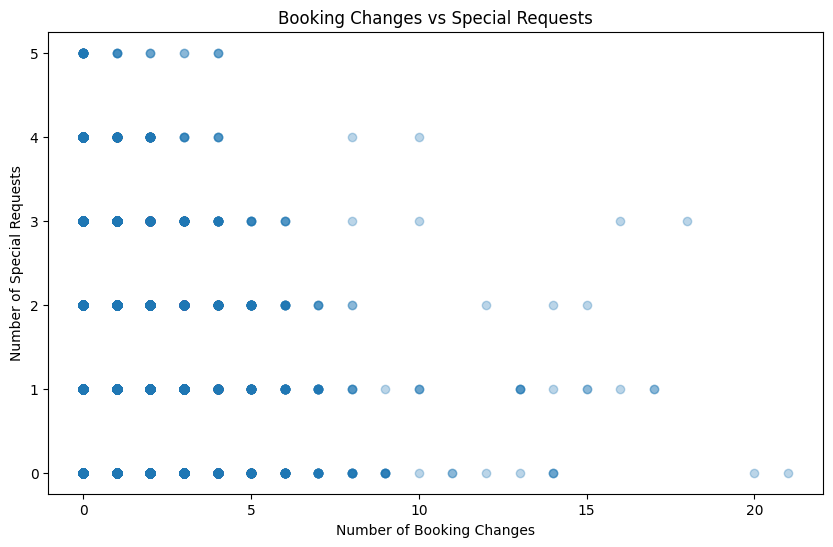

In [36]:
# Calculate correlation
booking_changes_requests_corr = (
    df['booking_changes'].corr(df['total_of_special_requests'])
)

print(
    f"Correlation between booking changes and special requests: "
    f"{booking_changes_requests_corr:.4f}"
)

# Visualization
plt.figure(figsize=(10, 6))

plt.scatter(
    df['booking_changes'],
    df['total_of_special_requests'],
    alpha=0.3
)

plt.title('Booking Changes vs Special Requests')
plt.xlabel('Number of Booking Changes')
plt.ylabel('Number of Special Requests')

plt.show()

Question 4

Cancellation Rate by Arrival Month:


arrival_date_month
January      22.08
February     23.17
March        24.33
April        30.37
May          29.10
June         30.27
July         31.74
August       32.15
September    24.41
October      23.59
November     21.04
December     26.79
Name: is_canceled, dtype: float64


Month with the highest cancellation rate: August
Cancellation rate: 32.15%


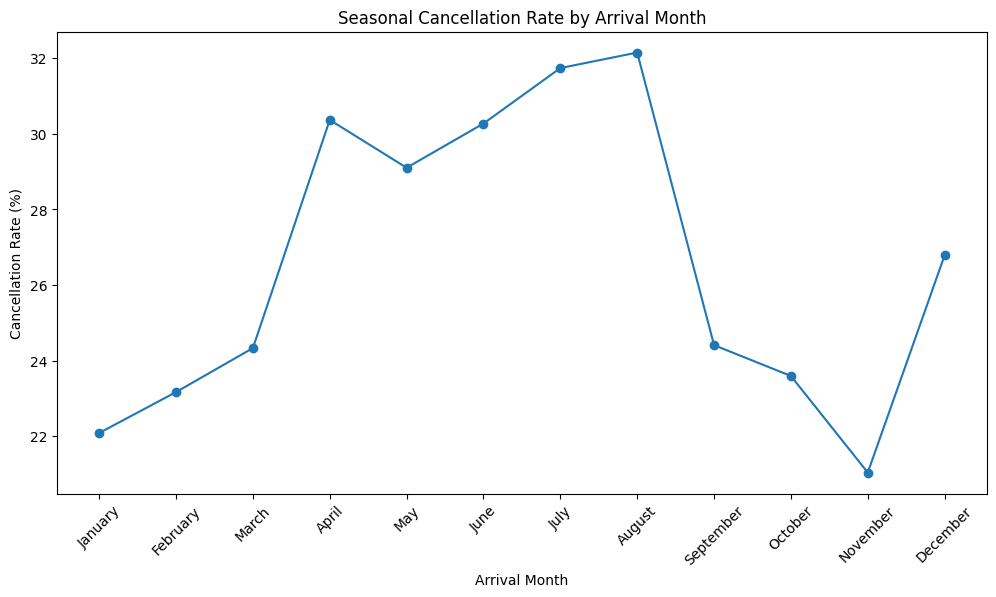

In [37]:
# Define month order
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

# Calculate cancellation rate by arrival month
seasonal_cancellation = (
    df.groupby('arrival_date_month')['is_canceled']
    .mean() * 100
)

# Arrange months chronologically
seasonal_cancellation = seasonal_cancellation.reindex(month_order)

print("Cancellation Rate by Arrival Month:")
display(seasonal_cancellation.round(2))

# Identify month with highest cancellation rate
highest_cancellation_month = seasonal_cancellation.idxmax()
highest_cancellation_rate = seasonal_cancellation.max()

print(
    f"\nMonth with the highest cancellation rate: "
    f"{highest_cancellation_month}"
)
print(
    f"Cancellation rate: {highest_cancellation_rate:.2f}%"
)

# Visualization
plt.figure(figsize=(12, 6))

plt.plot(
    seasonal_cancellation.index,
    seasonal_cancellation.values,
    marker='o'
)

plt.title('Seasonal Cancellation Rate by Arrival Month')
plt.xlabel('Arrival Month')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45)

plt.show()

Question 5

<Figure size 1200x600 with 0 Axes>

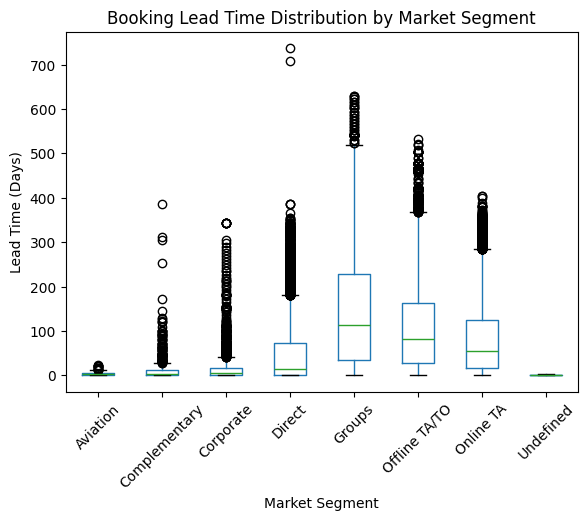

In [38]:
plt.figure(figsize=(12, 6))

df.boxplot(
    column='lead_time',
    by='market_segment',
    grid=False
)

plt.title('Booking Lead Time Distribution by Market Segment')
plt.suptitle('')
plt.xlabel('Market Segment')
plt.ylabel('Lead Time (Days)')
plt.xticks(rotation=45)

plt.show()